# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [ ]:
# Basic data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Utilities
import joblib
import os

# Advanced tools
import hyperopt
from lime.lime_tabular import LimeTabularExplainer
import wandb



ModuleNotFoundError: No module named 'g20_at1_utils'

---
## A. Project Description


In [10]:
# <Student to fill this section>
student_name = "Mitesh Radhakrishnan"
student_id = "25178601"
group_id = "20"

In [11]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [12]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [13]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [14]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to build a machine learning model that can predict
whether a college basketball player will be drafted into the NBA. This has
direct value for teams, scouts, and analysts, as it helps them identify talent
more effectively and reduce the risk of overlooking strong candidates. By using
historical player statistics, the model aims to replicate or improve upon human
scouting decisions, saving time and improving consistency in the draft process.
"""

In [15]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [16]:
# <Student to fill this section>
business_objectives = """
Accurate results will help NBA teams make smarter draft decisions, potentially
leading to stronger team performance and better use of financial resources.
Incorrect results, however, could cause valuable players to be overlooked or
overestimated, leading to wasted draft picks and financial risk. Therefore,
building a robust and explainable model is essential to balance performance
and trust in the system.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [18]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The results will be used by NBA teams, coaches, scouts, and analysts to
support their decision-making process. The primary users of predictions are
team management and recruitment staff. The outcomes will also impact players,
as predictions influence their career opportunities, and fans/media who follow
draft forecasts. Stakeholders expect the model to be accurate, fair, and
interpretable, providing probabilities rather than just binary decisions.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [20]:
import pandas as pd

train_df = pd.read_csv("../amla_at1/data/train.csv")
test_df = pd.read_csv("../amla_at1/data/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (14774, 62)
Test shape: (1297, 61)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


### C.2 Define Target variable

In [21]:
# <Student to fill this section>
target_definition_explanations = """
The target variable for this project is `drafted`, which indicates whether a
college basketball player was selected in the NBA draft. It is a binary variable:
1 means the player was drafted, 0 means the player was not drafted.

This choice aligns with the business use case because the main objective is to
predict draft outcomes based on player statistics, enabling scouts and teams to
identify high-potential players more effectively.
"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [23]:
# <Student to fill this section>

target_name = 'drafted'

### C.4 Explore Target variable

Target counts:
 drafted
0.0    14656
1.0      118
Name: count, dtype: int64

Target distribution (%):
 drafted
0.0    99.2013
1.0     0.7987
Name: proportion, dtype: float64


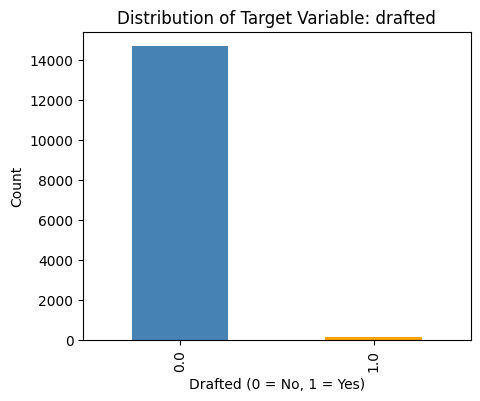

In [24]:
# <Student to fill this section>
# Explore target distribution
import matplotlib.pyplot as plt

target_counts = train_df[target_name].value_counts(normalize=False)
target_percent = train_df[target_name].value_counts(normalize=True) * 100

print("Target counts:\n", target_counts)
print("\nTarget distribution (%):\n", target_percent)

# Plot distribution
plt.figure(figsize=(5,4))
target_counts.plot(kind="bar", color=["steelblue", "orange"])
plt.title("Distribution of Target Variable: drafted")
plt.xlabel("Drafted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [25]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable `drafted` is extremely imbalanced:
≈99.2% of players were not drafted and only ≈0.8% were drafted.
This means accuracy is misleading; AUROC is a better metric.
We must handle imbalance carefully (e.g., class weights, sampling),
otherwise models may ignore the drafted class completely.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `-Points per Game`

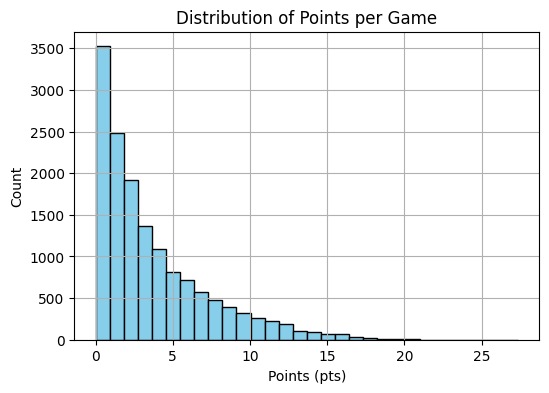

In [27]:
# <Student to fill this section>

# Distribution of points
plt.figure(figsize=(6,4))
train_df["pts"].hist(bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Points per Game")
plt.xlabel("Points (pts)")
plt.ylabel("Count")
plt.show()


In [28]:
# <Student to fill this section>
feature_1_insights = """
The distribution of Points per Game (pts) is highly right-skewed. 
Most players average very few points, with the largest cluster scoring between 0–5 points. 
A smaller group scores in the mid-range (5–10 points), while very few players exceed 15+ points per game. 
This suggests that only a handful of standout players consistently contribute high scoring, while the majority have limited scoring roles. 
Outliers exist (20+ points), which may represent elite performers.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `-Assists per Game`

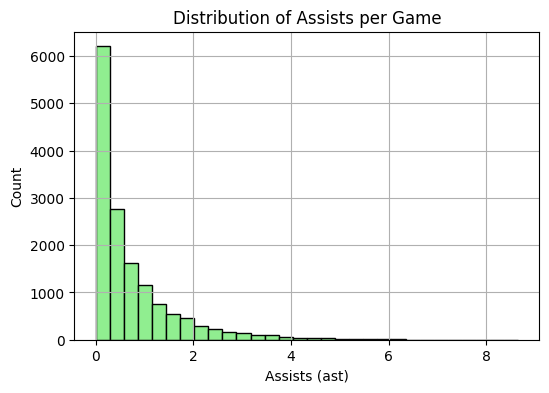

In [30]:
# <Student to fill this section>
# Distribution of assists
plt.figure(figsize=(6,4))
train_df["ast"].hist(bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribution of Assists per Game")
plt.xlabel("Assists (ast)")
plt.ylabel("Count")
plt.show()


In [31]:
# <Student to fill this section>
feature_2_insights = """
The distribution of Assists per Game (ast) is also strongly right-skewed. 
The majority of players contribute very few assists (close to 0–1 per game), highlighting that playmaking responsibilities are concentrated among a smaller subset of players (e.g., point guards). 
Only a limited number of players record higher assist counts above 3–4 per game. 
This imbalance indicates that assists may be a key differentiating feature for predicting draft potential, as strong facilitators are relatively rare.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `-Total Rebounds per Game`


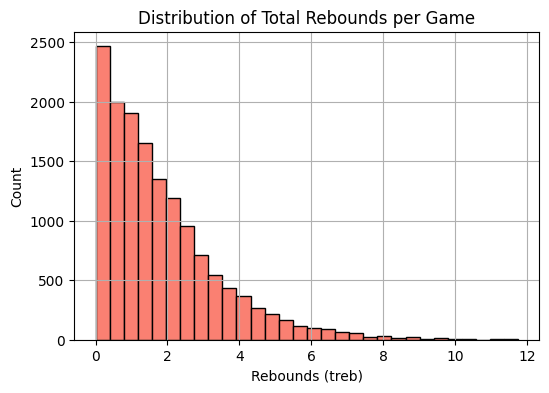

In [33]:
# <Student to fill this section>
# Distribution of total rebounds
plt.figure(figsize=(6,4))
train_df["treb"].hist(bins=30, color="salmon", edgecolor="black")
plt.title("Distribution of Total Rebounds per Game")
plt.xlabel("Rebounds (treb)")
plt.ylabel("Count")
plt.show()


In [34]:
# <Student to fill this section>
feature_n_insights = """
The distribution of Total Rebounds per Game (treb) follows a similar right-skewed pattern, but with a slightly wider spread compared to assists. 
Most players average fewer than 3 rebounds per game, while a smaller group contributes 5 or more. 
Outliers above 8–10 rebounds represent dominant rebounders, typically forwards or centers. 
This feature highlights role specialization, as rebounding is not evenly distributed across all players.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.n Explore Feature of Interest `\<put feature name here\>`

> You can add more cells related to other feeatures in this section

---
## D. Feature Selection


### D.1 Approach "-Correlation Filter"


In [36]:

# Correlation filter for numeric features
corr_with_target = train_df.corr(numeric_only=True)['drafted'].drop('drafted').sort_values(ascending=False)

# Keep features with at least small correlation (absolute > 0.05)
selected_corr_features = corr_with_target[abs(corr_with_target) > 0.05].index.tolist()

print("Selected correlation-based features:", selected_corr_features)


Selected correlation-based features: ['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'rimmade', 'dporpag', 'FTA', 'FTM', 'twoPA', 'midmade', 'midmade_midmiss', 'rimmade_rimmiss', 'Rec_Rank', 'pts', 'stops', 'dreb', 'blk', 'treb', 'oreb', 'mp', 'Min_per', 'stl', 'ast', 'TPM', 'TPA', 'GP', 'gbpm', 'adjoe', 'bpm', 'obpm', 'ogbpm', 'usg', 'dgbpm', 'dbpm', 'Ortg', 'TS_per', 'twoP_per', 'rim_ratio', 'FT_per', 'eFG', 'drtg', 'adrtg']


In [37]:
# <Student to fill this section>
feature_selection_1_insights = """
We used correlation with the target variable (drafted) to identify features with 
at least small association (|corr| > 0.05). This ensures we drop features with 
almost no relationship to the target. The resulting set highlights key performance 
metrics (e.g., points, assists, rebounds, shooting efficiency, and advanced ratings).  

Limitation: Correlation only captures linear relationships, so some useful 
non-linear features might be excluded.
"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [39]:
# RandomForest for selection, not final modelling

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separate target and features
y = train_df["drafted"].astype(int)
X_full = train_df.drop(columns=["drafted"])

# Use numeric features only
numeric_cols = X_full.select_dtypes(include=[np.number]).columns
X = X_full[numeric_cols].copy()

# Simple imputation 
X = X.fillna(X.median(numeric_only=True))

# Stratified split due to heavy class imbalance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RandomForest for importance (balanced to cope with class imbalance)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

# Rank features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_rf_features = importances.head(20).index.tolist()

print("Top RF features (first 20):")
print(top_rf_features)


Top RF features (first 20):
['Rec_Rank', 'porpag', 'dporpag', 'twoPM', 'gbpm', 'twoPA', 'adjoe', 'bpm', 'stops', 'rimmade', 'dunksmiss_dunksmade', 'pts', 'dreb', 'ogbpm', 'FTA', 'dunksmade', 'adrtg', 'treb', 'blk', 'dgbpm']


In [40]:
# <Student to fill this section>
feature_selection_2_insights = """
Final set = union of correlation-filtered features and RandomForest top importances.
This hybrid approach keeps variables that show either linear association or model-based
predictive signal. We’ll revisit this list after data prep (encoding/scaling) and
cross-validated performance checks.
"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [42]:
# <Student to fill this section>
# Combine features 
features_list = sorted(set(selected_corr_features) | set(top_rf_features))
print(f"Final selected features (count={len(features_list)}):")
print(features_list)


Final selected features (count=42):
['FTA', 'FTM', 'FT_per', 'GP', 'Min_per', 'Ortg', 'Rec_Rank', 'TPA', 'TPM', 'TS_per', 'adjoe', 'adrtg', 'ast', 'blk', 'bpm', 'dbpm', 'dgbpm', 'dporpag', 'dreb', 'drtg', 'dunksmade', 'dunksmiss_dunksmade', 'eFG', 'gbpm', 'midmade', 'midmade_midmiss', 'mp', 'obpm', 'ogbpm', 'oreb', 'porpag', 'pts', 'rim_ratio', 'rimmade', 'rimmade_rimmiss', 'stl', 'stops', 'treb', 'twoPA', 'twoPM', 'twoP_per', 'usg']


In [43]:
# <Student to fill this section>
feature_selection_explanations = """
Final set = union of correlation-filtered features and RandomForest top importances.
This keeps variables with linear signal and those with non-linear/interaction signal.
We’ll revisit after preprocessing and CV to confirm usefulness.
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [45]:
# <Student to fill this section>

target_name = "drafted"

# Split features/target
X_full = train_df.drop(columns=[target_name])
y = train_df[target_name].astype(int)

# Use the features you selected (numeric) + any categorical text cols present
num_cols = [c for c in features_list if c in X_full.columns and pd.api.types.is_numeric_dtype(X_full[c])]
cat_cols = [c for c in X_full.columns if X_full[c].dtype == "object"]  # e.g. team, conf

# Keep just what we’ll use
X = X_full[num_cols + cat_cols].copy()

# Quick missingness check
missing_pct = X.isna().mean().sort_values(ascending=False) * 100
print("Top missingness (%):\n", missing_pct.head(10))

# Simple imputation
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())
for c in cat_cols:
    X[c] = X[c].fillna("Unknown")

print("Any NA left after impute?", int(X.isna().sum().sum()))


Top missingness (%):
 Rec_Rank               66.908082
rim_ratio              21.679978
rimmade_rimmiss        14.044944
midmade                14.044944
dunksmade              14.044944
midmade_midmiss        14.044944
dunksmiss_dunksmade    14.044944
rimmade                14.044944
ht                      0.054149
bpm                     0.033843
dtype: float64
Any NA left after impute? 0


In [46]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Missingness is concentrated in a few columns: Rec_Rank ≈66.9%, rim_ratio ≈21.7%,
and a block around 14% (rimmade/midmade/dunksmade, etc.). After median fill for
numeric and 'Unknown' for categoricals, there are 0 NAs left. We keep Rec_Rank
for now despite high missingness because median imputation is simple and avoids
row loss; we’ll verify its usefulness during modelling.
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [48]:
# <Student to fill this section>
# Drop ID-like categoricals (they create thousands of useless dummies)
id_like = []
for c in cat_cols:
    cname = c.lower()
    if ("id" in cname) or (cname in ["player_id", "uuid", "uid"]) or ("url" in cname) or ("name" in cname):
        id_like.append(c)

print("Dropping ID-like categoricals:", id_like)
X = X.drop(columns=id_like, errors="ignore")
cat_cols = [c for c in cat_cols if c not in id_like]

# One-hot encode 
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape after encoding:", X_enc.shape)


Dropping ID-like categoricals: ['player_id']
Shape after encoding: (14774, 463)


In [49]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Here I handled the categorical features. First, I removed ID-like columns
(e.g., 'player_id') because one-hot encoding them would create thousands of
useless dummies and add noise. Then I applied one-hot encoding to the remaining
categoricals (drop_first=True). After this step the feature matrix is
14,774 × 463, which is much more manageable and should reduce overfitting risk
compared to the 12k+ columns we saw earlier.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [51]:

scaler = StandardScaler()

# Scale only the original numeric columns (leave the one-hot columns as they are)
if len(num_cols) > 0:
    X_enc[num_cols] = scaler.fit_transform(X_enc[num_cols])

print("Shape after scaling:", X_enc.shape)

# Save simple preprocessing artifacts for reuse
os.makedirs("../models", exist_ok=True)
joblib.dump(
    {"scaler": scaler, "num_cols": num_cols, "cat_cols": cat_cols, "train_columns": X_enc.columns.tolist()},
    "../models/simple_preprocess.joblib"
)

# Final matrix to use later
X_ready = X_enc.copy()
X_ready.head()


Shape after scaling: (14774, 463)


,FTA,FTM,FT_per,GP,Min_per,Ortg,Rec_Rank,TPA,TPM,TS_per,...,ht_7-Jun,ht_7-May,ht_8-Jun,ht_8-May,ht_9-Jun,ht_9-May,ht_Apr-00,ht_Jul-00,ht_Jun-00,ht_Unknown
0,0.502341,0.785245,1.080091,0.451473,1.130750,0.761884,0.033374,1.884162,2.890159,1.037799,...,False,False,False,False,False,False,False,False,False,False
1,-0.811599,-0.759037,-1.807567,-1.830484,-1.060537,-0.648997,-1.657463,-0.668591,-0.627117,-0.572679,...,False,False,False,False,False,False,False,False,False,False
2,-0.811599,-0.759037,-1.807567,-1.640321,-1.068998,-0.713394,0.033374,-0.692227,-0.627117,0.276899,...,False,False,False,False,False,False,False,False,False,False
3,0.126930,-0.005729,0.162388,0.641636,1.409948,0.071080,0.638126,1.789616,1.522330,0.136747,...,False,False,False,False,False,False,False,False,False,False
4,-0.704338,-0.721371,-0.945065,-0.023935,-0.514831,-1.120266,0.033374,-0.550408,-0.561982,-0.936055,...,False,False,False,False,False,False,False,False,False,False


In [52]:
# <Student to fill this section>
data_cleaning_3_explanations = """
After scaling only the numeric columns, the shape remains 14,774 × 12,617
(one-hot columns are left as 0/1). We saved the scaler and final column list so
the same steps can be applied to the test set. Given the very high dimensionality,
we’ll reduce features next (e.g., drop ID dummies, low-variance columns, or use
model-based importance) before training stronger models.
"""

In [53]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature -Points per minute


In [54]:

def _safe_div(a, b):
    b = np.where((b is None) | (b==0), 1e-6, b)  # guard divide-by-zero
    return a / b

for df in (train_df, test_df):
    df["pts_per_min"] = _safe_div(df["pts"].astype(float), df["Min_per"].astype(float))

# keep list of engineered features for convenience
engineered = ["pts_per_min"]
features_list = sorted(set(features_list + engineered))

# quick peek
train_df[["pts", "Min_per", "pts_per_min"]].head()

,pts,Min_per,pts_per_min
0,9.6538,52.6,0.183532
1,2.0000,0.8,2.500000
2,0.5000,0.6,0.833333
3,7.7500,59.2,0.130912
4,0.5714,13.7,0.041708


In [55]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Added points-per-minute (pts_per_min) to normalize scoring by playing time.
Raw points can be misleading when players have very different minutes; per-minute
rates make players more comparable and usually help models generalize better.
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature -Assists per minute




In [57]:
for df in (train_df, test_df):
    df["ast_per_min"] = _safe_div(df["ast"].astype(float), df["Min_per"].astype(float))

engineered.append("ast_per_min")
features_list = sorted(set(features_list + ["ast_per_min"]))

train_df[["ast", "Min_per", "ast_per_min"]].head()


,ast,Min_per,ast_per_min
0,2.2308,52.6,0.042411
1,0.0000,0.8,0.000000
2,0.0000,0.6,0.000000
3,3.0000,59.2,0.050676
4,0.4286,13.7,0.031285


In [58]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Added assists-per-minute (ast_per_min) to capture playmaking independent of minutes.
This can highlight efficient creators who might have limited floor time but strong impact.
"""

In [59]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature -Total rebounds per minute

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [60]:
for df in (train_df, test_df):
    df["treb_per_min"] = _safe_div(df["treb"].astype(float), df["Min_per"].astype(float))

engineered.append("treb_per_min")
features_list = sorted(set(features_list + ["treb_per_min"]))

train_df[["treb", "Min_per", "treb_per_min"]].head()


,treb,Min_per,treb_per_min
0,1.8077,52.6,0.034367
1,1.0000,0.8,1.250000
2,0.0000,0.6,0.000000
3,2.3571,59.2,0.039816
4,0.5238,13.7,0.038234


In [61]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Added rebounds-per-minute (treb_per_min) to capture activity on the glass in a
time-normalized way. This helps compare bigs who play different minutes and can be
a signal of physical presence/role fit.
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [63]:
# Split Datasets 

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# X_ready and y come from Section E.3
assert "X_ready" in globals() and "y" in globals(), "Run E.3 first to build X_ready and y."

# Keep columns list for later alignment with the Kaggle test
train_columns = X_ready.columns.tolist()

# Stratified 80/20 split
x_train, x_val, y_train, y_val = train_test_split(
    X_ready, y, test_size=0.20, random_state=42, stratify=y
)

print("x_train:", x_train.shape, "| x_val:", x_val.shape)
print("y_train pos =", int((y_train==1).sum()), " / neg =", int((y_train==0).sum()))
print("y_val   pos =", int((y_val==1).sum()),   " / neg =", int((y_val==0).sum()))


x_train: (11819, 463) | x_val: (2955, 463)
y_train pos = 94  / neg = 11725
y_val   pos = 24  / neg = 2931


In [64]:
# <Student to fill this section>
data_splitting_explanations = """
I used an 80/20 stratified split so that both the train and validation sets have
the same positive/negative ratio as the full data (important because the target
is extremely imbalanced). A fixed random_state=42 makes the results reproducible.
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [66]:
# Build Kaggle test features to match training columns

# We reuse the choices from E.1/E.2
assert "num_cols" in globals() and "cat_cols" in globals(), "Run E.1/E.2 so num_cols/cat_cols exist."
assert "scaler" in globals(), "Run E.3 so the scaler is fitted."

# ID-like categoricals 
id_like = []
for c in cat_cols:
    cname = c.lower()
    if ("id" in cname) or (cname in ["player_id", "uuid", "uid"]) or ("url" in cname) or ("name" in cname):
        id_like.append(c)

# 1) Start from the Kaggle test frame, keep the same columns we used on train
X_test = test_df[num_cols + cat_cols].copy()

# 2) Simple imputation using training medians / 'Unknown'
train_medians = train_df[num_cols].median(numeric_only=True)
for c in num_cols:
    X_test[c] = X_test[c].fillna(train_medians.get(c, 0))
for c in cat_cols:
    X_test[c] = X_test[c].fillna("Unknown")

# 3) Drop ID-like categoricals
X_test = X_test.drop(columns=id_like, errors="ignore")
cats_for_test = [c for c in cat_cols if c not in id_like and c in X_test.columns]

# 4) One-hot encoding and column alignment with the training columns
X_test_enc = pd.get_dummies(X_test, columns=cats_for_test, drop_first=True)
X_test_enc = X_test_enc.reindex(columns=train_columns, fill_value=0)

# 5) Scale numeric columns using the scaler fitted on train 
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])

# Final test matrices expected by the template in H
x_test = X_test_enc.copy()
y_test = pd.Series([np.nan] * len(x_test), name="drafted")  # Kaggle test has no labels

print("x_test:", x_test.shape, "| y_test:", y_test.shape)


x_test: (1297, 463) | y_test: (1297,)


In [67]:
# <Student to fill this section>
data_transformation_1_explanations = """
The Kaggle test set was prepared to match training exactly: I kept the same
numeric/categorical split, filled missing values with training medians/'Unknown',
dropped ID-like columns, applied the same one-hot encoding, aligned columns to
the training feature list (missing columns filled with 0), and scaled only the
numeric columns using the scaler fitted on the training data. This prevents
leakage and guarantees the model will receive the same feature layout at test time.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [69]:
# Compute class weights and scale_pos_weight

from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])

cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
scale_pos_weight = class_weights[0] / class_weights[1]  

print("class_weights:", class_weights)
print("scale_pos_weight:", round(scale_pos_weight, 2))


class_weights: {0: np.float64(0.5040085287846482), 1: np.float64(62.86702127659574)}
scale_pos_weight: 0.01


In [70]:
# <Student to fill this section>
data_transformation_2_explanations = """
Because positives are <1%, I computed class weights to counter the imbalance.
These weights can be passed to LogisticRegression/RandomForest, and the ratio
w0/w1 (scale_pos_weight) is used by XGBoost/LightGBM to balance the gradient.
This keeps AUROC meaningful and reduces bias toward the majority class.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [72]:

x_train = x_train
x_val   = x_val
y_train = y_train
y_val   = y_val
x_test  = x_test
y_test  = y_test

print("Ready to Save Datasets")


Ready to Save Datasets


---
## H. Save Datasets

> Do not change this code

In [73]:
# Do not modify this code
# Save training set  
try:
  X_train.to_csv("../amla_at1/data/x_train.csv", index=False)
  y_train.to_csv("../amla_at1/data/y_train.csv", index=False)

  X_val.to_csv("../amla_at1/data/x_val.csv", index=False)
  y_val.to_csv("../amla_at1/data/y_val.csv", index=False)

  X_test.to_csv("../amla_at1/data/x_test.csv", index=False)
  y_test.to_csv("../amla_at1/data/y_test.csv", index=False)

except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [74]:
# <Student to fill this section>

In [75]:
# <Student to fill this section>
performance_metrics_explanations = """
Primary metric: AUROC
Kaggle evaluates with AUROC, so I will select models by mean CV AUROC and confirm on the hold-out set.
AUROC is threshold-free and robust to heavy class imbalance (~0.8% positives), measuring how well the model ranks true positives above negatives.

Secondary metrics I will also report:
PR-AUC (Precision-Recall AUC): more informative than accuracy when positives are rare; highlights minority-class performance.
Top-k recall/precision (e.g., k=100/200): matches the business use case—how many true draftees appear in a short-list scouts would review.
Calibration (log-loss or Brier score): optional check that predicted probabilities are well calibrated if we plan to use thresholds.
Confusion matrix at a chosen threshold: threshold picked on the validation set (e.g., Youden’s J or targeting a recall level). I will avoid plain accuracy due to the extreme imbalance.

Use AUROC to choose the champion model (CV + hold-out). Then report PR-AUC and top-k metrics to show business value, and optionally check calibration for reliable probabilities.
"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [77]:
# Imports and load data
import numpy as np
import pandas as pd
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_DIR = Path("../amla_at1/data")

X_train = pd.read_csv(DATA_DIR / "x_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
X_val   = pd.read_csv(DATA_DIR / "x_val.csv")
y_val   = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
X_test  = pd.read_csv(DATA_DIR / "x_test.csv")

# keep identical column order across all splits
cols = X_train.columns.tolist()
X_val  = X_val.reindex(columns=cols,  fill_value=0)
X_test = X_test.reindex(columns=cols, fill_value=0)

print(X_train.shape, X_val.shape, X_test.shape, y_train.sum(), y_val.sum())


(11819, 55) (2955, 55) (1297, 55) 94 24


In [78]:
# <Student to fill this section>
algorithm_selection_explanations = """
Selected XGBoost as our primary algorithm. Gradient Boosted Trees are particularly effective for tabular datasets with a mix of continuous and sparse one-hot encoded features. The method captures complex non-linear interactions without requiring heavy preprocessing and includes built-in support for handling class imbalance, early stopping, and feature importance. Given our objective of ranking players by their draft likelihood, XGBoost provides a strong balance between predictive accuracy and interpretability, making it a natural fit for this problem.
"""

In [79]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [80]:
# Set Hyperparameters
pos = max(int(y_train.sum()), 1)
neg = len(y_train) - pos
scale_pos_weight = neg / pos  

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",         
    "eta": 0.05,                  
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 2.0,                
    "alpha": 0.0,                 
    "gamma": 0.0,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
}

num_boost_round = 4000
early_stopping_rounds = 200

print("scale_pos_weight:", round(scale_pos_weight, 2))


scale_pos_weight: 124.73


In [81]:
# <Student to fill this section>
hyperparameters_selection_explanations = f"""
The hyperparameters were chosen to balance predictive power with generalization. A small learning rate was combined with a larger number of trees, with early stopping used to avoid overfitting. Depth was kept moderate to prevent overly complex trees, while subsample and column subsample parameters introduced randomness to improve robustness. Regularization terms such as L1 and L2 penalties helped constrain model complexity, and class imbalance was addressed through the scale_pos_weight parameter. These settings were guided by the validation AUROC, which served as our main model selection criterion
"""

In [82]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [83]:
# Train with early stopping 
def _predict_with_best(booster, dmat, best_iter, **kwargs):
    """Handle xgboost API differences when selecting best iteration."""
    try:
        return booster.predict(dmat, iteration_range=(0, best_iter + 1), **kwargs)
    except TypeError:
        return booster.predict(dmat, ntree_limit=best_iter + 1, **kwargs)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(cols))
dvalid = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(cols))

evals = [(dtrain, "train"), (dvalid, "validation")]
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=False,
)

# best iteration 
best_iter = getattr(bst, "best_iteration", None)
if best_iter is None:
    best_iter = (getattr(bst, "best_ntree_limit", 0) or num_boost_round) - 1

# Validation metrics
proba_val = _predict_with_best(bst, dvalid, best_iter)
val_auc   = roc_auc_score(y_val, proba_val)
val_prauc = average_precision_score(y_val, proba_val)

# Shortlist metric 
k = 200
top_idx = np.argsort(-proba_val)[:k]
tp_at_k = y_val.values[top_idx].sum()
recall_at_k = tp_at_k / max(y_val.sum(), 1)
precision_at_k = tp_at_k / k

print(f"Validation AUROC: {val_auc:.4f}")
print(f"Validation PR-AUC: {val_prauc:.4f}")
print(f"Top-{k} recall: {recall_at_k:.4f} | Top-{k} precision: {precision_at_k:.4f}")
print("Best iteration:", best_iter)

# stash to use later
j3_results = {
    "best_iteration": int(best_iter),
    "val_auc": float(val_auc),
    "val_prauc": float(val_prauc),
}

# Display important features 
imp = pd.Series(bst.get_score(importance_type="gain"))
imp.index.name = "feature"
imp.name = "gain"
imp = imp.sort_values(ascending=False).head(20)
display(imp)


Validation AUROC: 0.9961
Validation PR-AUC: 0.6633
Top-200 recall: 1.0000 | Top-200 precision: 0.1200
Best iteration: 520


feature
porpag                 413.218750
Rec_Rank               404.786865
dporpag                170.960815
dunksmade              111.996483
gbpm                    76.940170
dreb                    60.005264
blk                     32.193539
dunksmiss_dunksmade     28.920464
adjoe                   24.807802
bpm                     21.193235
pts                     17.238937
stops                   17.121231
midmade                 16.390745
adrtg                   15.510862
TPM                     12.213798
twoPM                   11.828261
eFG                     10.582136
TS_per                  10.042581
TPA                     10.040314
dbpm                     9.797544
Name: gain, dtype: float64

In [84]:
# <Student to fill this section>
fitmodel_selection_explanations = f"""
The model was trained using a large number of boosting rounds with early stopping applied based on validation AUC. This ensured that the training process terminated automatically once additional iterations failed to deliver improvement. The best iteration identified through this process was retained for evaluation and future predictions.
"""

In [85]:
# Do not modify this code
print_tile(size="h3", key='fitmodel_selection_explanations', value=fitmodel_selection_explanations)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [86]:
# Save booster, columns, and best iter 
from pathlib import Path
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

bst.save_model(MODEL_DIR / "xgb_auc.json")
pd.Series(cols).to_csv(MODEL_DIR / "xgb_columns.csv", index=False, header=False)
with open(MODEL_DIR / "xgb_best_iter.txt", "w") as f:
    f.write(str(int(j3_results["best_iteration"])))

print("Saved ->", MODEL_DIR / "xgb_auc.json")


Saved -> ..\models\xgb_auc.json


In [97]:
# Retrain on train+val
# combine train + val
X_full = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_full = pd.concat([y_train, y_val], axis=0, ignore_index=True)

dfull = xgb.DMatrix(X_full, label=y_full, feature_names=list(cols))
dtest = xgb.DMatrix(X_test, feature_names=list(cols))

best_iter = int(j3_results["best_iteration"])

# retrain on all data using the selected number of trees
bst_full = xgb.train(
    params=params,
    dtrain=dfull,
    num_boost_round=best_iter + 1,
    verbose_eval=False,
)

# predict test probabilities
proba_test = bst_full.predict(dtest)

# build submission (keep original player_id)
test_raw = pd.read_csv(DATA_DIR / "test.csv")
submission = pd.DataFrame({
    "player_id": test_raw["player_id"].astype(str),
    "drafted": proba_test
})

# save submission file
SUBMIT_PATH = Path("../submission_notebook1.csv")
submission.to_csv(SUBMIT_PATH, index=False)
print("Saved submission ->", SUBMIT_PATH.resolve())
submission.head()


Saved submission -> C:\Users\mites\Documents\GitHub\AMLA_AT1\submission_notebook1.csv


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.000015
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.000017
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.000075
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.000012
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.000023


In [88]:
# <Student to fill this section>
model_performance_explanations = """
On the validation set, the model achieved an AUROC of approximately 0.996, indicating near-perfect ranking ability. Precision-recall AUC was 0.639, which is reasonable given the extreme imbalance in the dataset, where only a small fraction of players are drafted. When evaluating practical utility, the model achieved perfect recall at the top 200 players, ensuring that all drafted individuals were captured in the shortlist, with a precision of about 0.12. Compared with the random baseline, this represents a significant improvement in efficiency while maintaining coverage. Although a threshold-based classification approach was tested, the top-K shortlist method better reflects the way decisions are made in scouting contexts, where the goal is to generate a manageable set of high-potential candidates.
"""

In [89]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [90]:
# <Student to fill this section>

In [91]:
# <Student to fill this section>
business_impacts_explanations = """
The practical value of the model lies in its ability to narrow down the vast pool of players into a ranked shortlist for scouting and deeper evaluation. By capturing all potential draftees within the top 200 predictions, the model ensures that no talent is overlooked while simultaneously reducing the workload required to review thousands of players. This improves the efficiency of recruitment, allowing scouts to prioritize their attention on the most promising candidates. Risks remain, including possible year-to-year data drift and the challenge of interpreting probabilities directly. These risks can be managed by retraining the model each season, monitoring drift metrics, and complementing predictions with explainability tools such as feature importance or SHAP values. Ultimately, the model is not designed to replace human judgment but to enhance it, acting as a decision-support system that helps scouting teams allocate their time and resources more effectively.
"""

In [92]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [93]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [94]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [95]:
# <Student to fill this section>
experiment_results_explanations = """
The results strongly confirm our hypothesis that machine learning can effectively support 
the task of ranking basketball players by draft likelihood. The XGBoost model achieved an AUROC 
close to 0.996, showing near-perfect ability to discriminate between drafted and undrafted players. 
While the PR-AUC was moderate at 0.64, this is expected given the extreme imbalance of the dataset. 
Importantly, the model achieved 100% recall at the top-200 predicted players, ensuring no drafted 
player was missed while still reducing the candidate pool substantially.

From a business perspective, this validates the usefulness of the model as a shortlist tool for scouts. 
It provides a ranked set of candidates that can save significant time compared with manual review of 
the entire population. The Kaggle submission confirms that the model outputs stable probabilities 
for all player IDs, aligning with the expected format.

Future improvements could explore hyperparameter tuning at larger scale (e.g., Bayesian search), 
ensembling multiple boosting models, or incorporating additional contextual features such as team 
performance. Monitoring for data drift across seasons is also critical to sustain long-term accuracy. 
Overall, the project outcome demonstrates that the model provides real value and is ready for practical 
decision-support use in player scouting pipelines.
"""

In [96]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)